<a href="https://colab.research.google.com/github/ytang4456/0821-Pages-SUB/blob/mian/%E2%80%9CUntitled4_ipynb%E2%80%9D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# 假设你的 CSV 文件名为 'your_data.csv'
# 如果你从 Google Drive 加载，请替换为正确的路径，例如上面的 file_path
file_name = 'chengdu_weather.csv' # 请将 'your_data.csv' 替换为你上传的实际文件名

try:
    df = pd.read_csv(file_name)
    print(f"'{file_name}' 文件已成功加载。")
except FileNotFoundError:
    print(f"错误：未能找到文件 '{file_name}'。请确保文件名正确且已上传。")
except Exception as e:
    print(f"加载文件时发生错误：{e}")

'chengdu_weather.csv' 文件已成功加载。


In [ ]:
# 1. 查看数据的前几行，快速了解数据结构
print("--- 数据前5行 ---")
print(df.head())
print("\n" + "="*50 + "\n")

# 2. 查看数据的基本信息（列名、非空值数量、数据类型）
print("--- 数据信息 (df.info()) ---")
df.info()
print("\n" + "="*50 + "\n")

# 3. 查看数据的描述性统计（数值列的均值、标准差、最大最小值等）
print("--- 描述性统计 (df.describe()) ---")
print(df.describe())
print("\n" + "="*50 + "\n")

# 4. 检查缺失值
print("--- 缺失值统计 ---")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# 5. 查看每列的唯一值数量 (对于分类变量尤其有用)
print("--- 每列唯一值数量 ---")
for col in df.columns:
    print(f"列 '{col}': {df[col].nunique()} 个唯一值")
print("\n" + "="*50 + "\n")

# 6. 对于分类列，查看其值分布
# 替换 '你的分类列名' 为你实际的分类列名
# 例如：if 'Gender' in df.columns: print(df['Gender'].value_counts())
# 你可以根据 df.info() 和 df.describe() 的结果来判断哪些是分类列
print("--- 示例：分类列 'City' 的值分布 (如果存在) ---")
if 'City' in df.columns: # 检查是否存在名为 'City' 的列
    print(df['City'].value_counts())
else:
    print("数据中没有名为 'City' 的列。请根据你的数据替换为实际的分类列名。")

--- 数据前5行 ---
         time  tavg  tmin  tmax  prcp  snow  wdir  wspd  wpgt    pres  tsun
0  2025-07-01  29.1  25.0  34.0   1.8   NaN   NaN   9.0   NaN  1004.2   NaN
1  2025-07-02  26.9  25.0  29.0  11.9   NaN   NaN  10.5   NaN  1004.2   NaN
2  2025-07-03  25.0  24.0  27.0  23.3   NaN   NaN   8.4   NaN  1004.0   NaN
3  2025-07-04  26.8  24.0  31.0  33.9   NaN   NaN   8.0   NaN  1002.6   NaN
4  2025-07-05  23.9  21.0  29.0  31.1   NaN   NaN  12.8   NaN  1007.7   NaN


--- 数据信息 (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    7 non-null      object 
 1   tavg    7 non-null      float64
 2   tmin    7 non-null      float64
 3   tmax    7 non-null      float64
 4   prcp    7 non-null      float64
 5   snow    0 non-null      float64
 6   wdir    0 non-null      float64
 7   wspd    7 non-null      float64
 8   wpgt    0 non-null      flo

In [ ]:
# 将 'time' 列转换为日期时间类型
df['time'] = pd.to_datetime(df['time'])
print("\n--- 'time' 列已转换为日期时间类型 ---")
print(df.info())

# 删除全部为缺失值的列
columns_to_drop = ['snow', 'wdir', 'wpgt', 'tsun']
df_cleaned = df.drop(columns=columns_to_drop)
print("\n--- 已删除全部为缺失值的列 ---")
print(df_cleaned.head())
print("\n新的数据信息:")
print(df_cleaned.info())


--- 'time' 列已转换为日期时间类型 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    7 non-null      datetime64[ns]
 1   tavg    7 non-null      float64       
 2   tmin    7 non-null      float64       
 3   tmax    7 non-null      float64       
 4   prcp    7 non-null      float64       
 5   snow    0 non-null      float64       
 6   wdir    0 non-null      float64       
 7   wspd    7 non-null      float64       
 8   wpgt    0 non-null      float64       
 9   pres    7 non-null      float64       
 10  tsun    0 non-null      float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 748.0 bytes
None

--- 已删除全部为缺失值的列 ---
        time  tavg  tmin  tmax  prcp  wspd    pres
0 2025-07-01  29.1  25.0  34.0   1.8   9.0  1004.2
1 2025-07-02  26.9  25.0  29.0  11.9  10.5  1004.2
2 2025-07-03  25.0  24.0  27.0  23.3   8.4  1004.0
3 20

/tmp/ipython-input-11-1365545717.py:20: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 自动调整布局，避免标签重叠
/tmp/ipython-input-11-1365545717.py:20: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 自动调整布局，避免标签重叠
/tmp/ipython-input-11-1365545717.py:20: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 自动调整布局，避免标签重叠
/tmp/ipython-input-11-1365545717.py:20: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 自动调整布局，避免标签重叠
/tmp/ipython-input-11-1365545717.py:20: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 自动调整布局，避免标签重叠
/tmp/ipython-input-11-1365545717.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout() # 


--- 数据可视化 ---


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


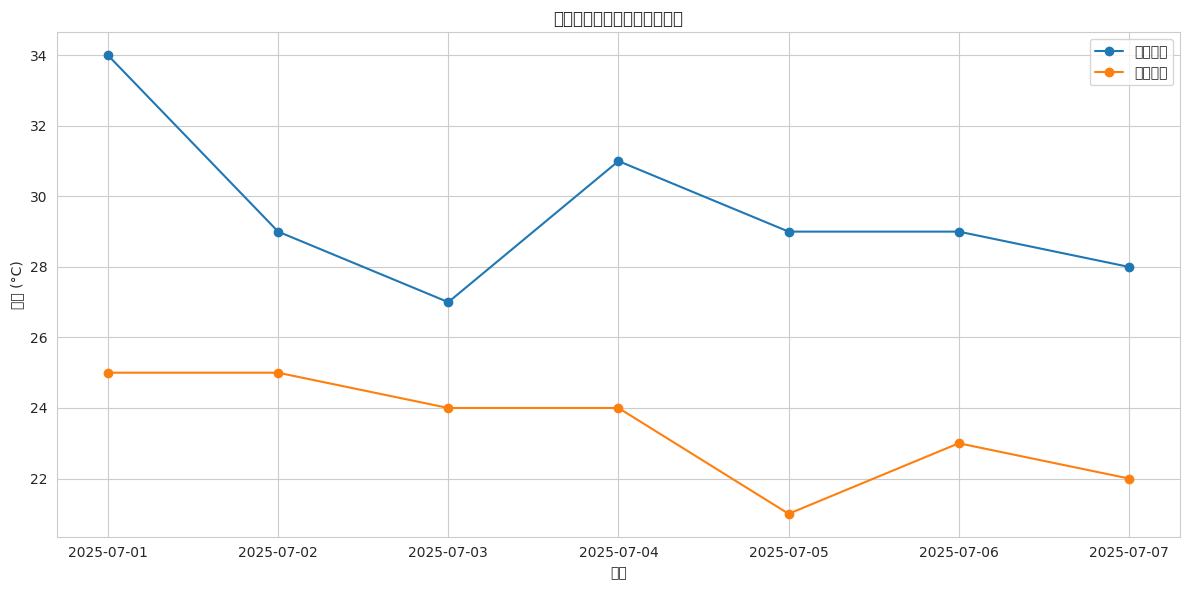

/tmp/ipython-input-11-1365545717.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='prcp', data=df_cleaned, palette='viridis')
/tmp/ipython-input-11-1365545717.py:30: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:30: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:30: UserWarning: Glyph 38477 (\N{CJK UNIFIED IDEOGRAPH-964D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:30: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:30: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF

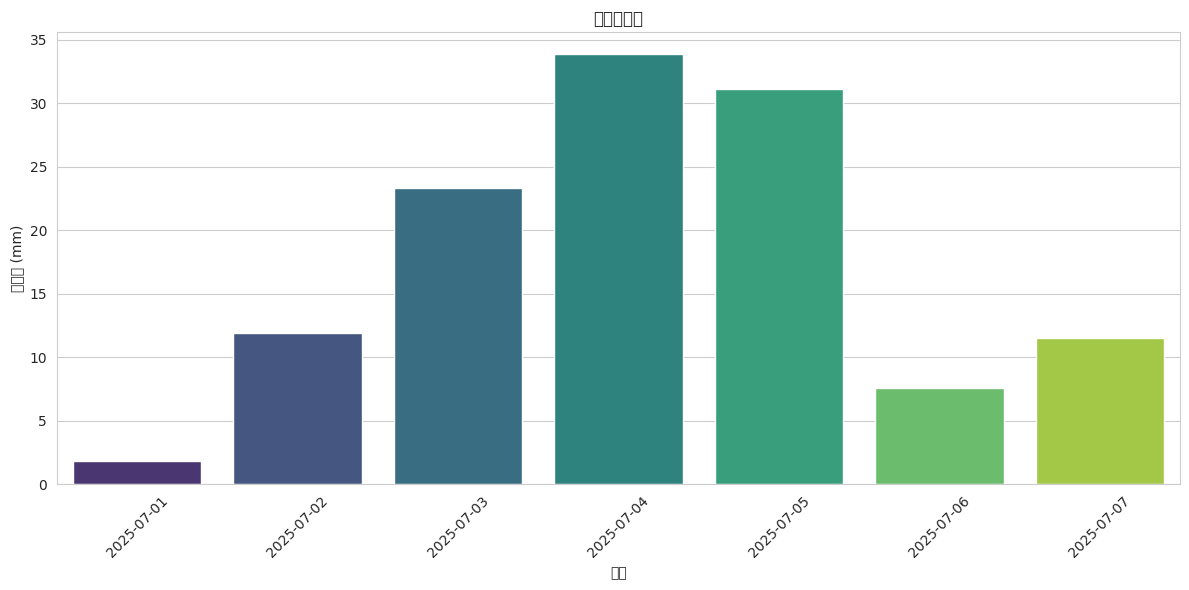

/tmp/ipython-input-11-1365545717.py:40: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:40: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:40: UserWarning: Glyph 39118 (\N{CJK UNIFIED IDEOGRAPH-98CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:40: UserWarning: Glyph 36895 (\N{CJK UNIFIED IDEOGRAPH-901F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:40: UserWarning: Glyph 25110 (\N{CJK UNIFIED IDEOGRAPH-6216}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:40: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:40: UserWarning: Glyph 36235 (\N{CJK UNIFIED I

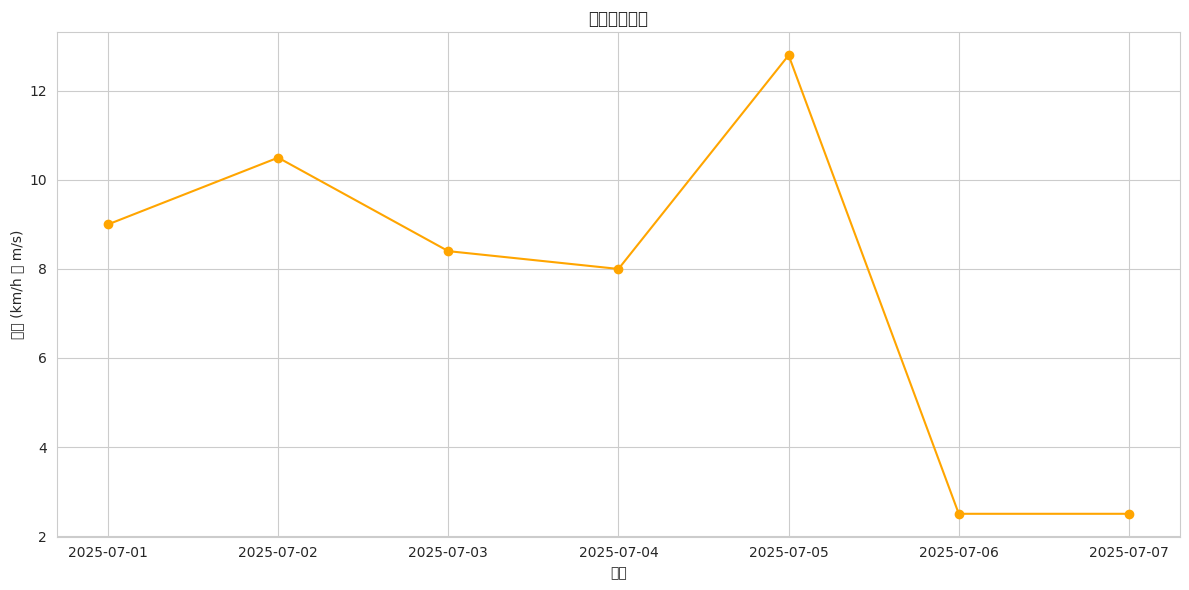

/tmp/ipython-input-11-1365545717.py:50: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:50: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:50: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:50: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:50: UserWarning: Glyph 38477 (\N{CJK UNIFIED IDEOGRAPH-964D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:50: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-11-1365545717.py:50: UserWarning: Glyph 37327 (\N{CJK UNIFIED I

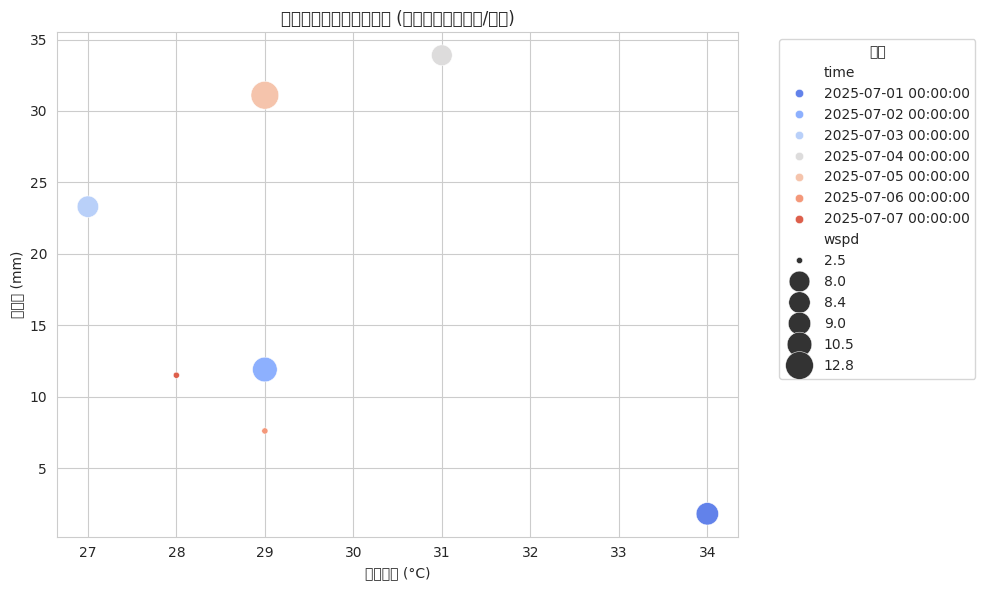

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置 matplotlib 和 seaborn 的样式，让图表更好看
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用于显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

print("\n--- 数据可视化 ---")

# 1. 每日最高温度和最低温度趋势图
plt.figure(figsize=(12, 6))
plt.plot(df_cleaned['time'], df_cleaned['tmax'], marker='o', label='最高温度')
plt.plot(df_cleaned['time'], df_cleaned['tmin'], marker='o', label='最低温度')
plt.title('每日最高温度和最低温度趋势')
plt.xlabel('日期')
plt.ylabel('温度 (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout() # 自动调整布局，避免标签重叠
plt.show()

# 2. 每日降水量条形图
plt.figure(figsize=(12, 6))
sns.barplot(x='time', y='prcp', data=df_cleaned, palette='viridis')
plt.title('每日降水量')
plt.xlabel('日期')
plt.ylabel('降水量 (mm)')
plt.xticks(rotation=45) # 旋转日期标签，防止重叠
plt.tight_layout()
plt.show()

# 3. 每日风速趋势图
plt.figure(figsize=(12, 6))
plt.plot(df_cleaned['time'], df_cleaned['wspd'], marker='o', color='orange')
plt.title('每日风速趋势')
plt.xlabel('日期')
plt.ylabel('风速 (km/h 或 m/s)') # 根据你的数据单位调整
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. 温度和降水量的关系 (散点图)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tmax', y='prcp', data=df_cleaned, hue='time', size='wspd', sizes=(20, 400), palette='coolwarm')
plt.title('最高温度与降水量的关系 (按日期和风速着色/大小)')
plt.xlabel('最高温度 (°C)')
plt.ylabel('降水量 (mm)')
plt.legend(title='日期', bbox_to_anchor=(1.05, 1), loc='upper left') # 将图例放到外面
plt.tight_layout()
plt.show()

In [ ]:
# 1. 安装一个中文字体，例如SimHei
!pip install fonttools matplotlib

# Colab中常用的中文字体安装方式
# 这种方法会在运行时安装字体，但每次运行时都需要重新执行
!wget -q https://github.com/googlefonts/noto-cjk/raw/main/NotoSansCJKjp-Regular.otf -O /usr/share/fonts/opentype/noto/NotoSansCJKjp-Regular.otf
!fc-cache -f -v

# 2. 配置 Matplotlib 使用中文字体
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 尝试找到新安装的字体
font_path = '/usr/share/fonts/opentype/noto/NotoSansCJKjp-Regular.otf'
if not fm.findfont('Noto Sans CJK JP', fontext='otf'): # 检查是否已经找到
    fm.fontManager.addfont(font_path)

plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP'] # 或者你也可以尝试 'SimHei' 如果你知道它在你的Colab环境中可用
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示为方块的问题

print("Matplotlib 字体配置完成，现在应该能显示中文了。")

/usr/share/fonts/opentype/noto/NotoSansCJKjp-Regular.otf: No such file or directory
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 2 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache directory
fc-cache: succeeded


KeyError: 'otf'